In [1]:


##### R 3.6.3


rm(list=ls())
gc()


library(tidyverse) #v1.3.0
library(tidyr)  #v1.1.4
library(Rphenograph)  #v0.99.1
library(ggpubr)   #v0.4.0
library(ggthemes) #v4.2.0
library(Rtsne)  #v0.15
library(flowCore)   #v1.52.1
library(Rcpp)  #v1.0.5
#library(cytofkit)   #v0.99.0
library(igraph) #v1.2.6
#library(cytofexplorer)  #v0.1.0
library(survival)   #v3.2.7
library(survminer)  #v0.4.8
library(pheatmap)  #v1.0.12
library(ggsci)  #v2.9

# load CP-based-CN40  --------------------------------------------
#gc_csd_CN <- read_csv(file = 'E:\\myPythonProject\\TrainingData\\20220317 AllsubtypeCN\\cells_r=50_CN=40.csv')
gc_csd_CN <- read_csv(file = '/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/cells_r=50_CN=40.csv')
# CN annotation ---------------------------------------------------
gc_csd_CN_anno <- gc_csd_CN %>% mutate(All_CN=paste0('CN',neighborhood10))
# 假设 gc_csd_CN_annoAll_CN 是一个 pandas Series
gc_csd_CN_annoAll_CN=gc_csd_CN_anno
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN0'] = 'CN0_1-7'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN1'] = 'CN1_15-6'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN2'] = 'CN2_2'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN3'] = 'CN3_10'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN4'] = 'CN4_8'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN5'] = 'CN5_4-5'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN6'] = 'CN6_14'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN7'] = 'CN7_6'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN8'] = 'CN8_13'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN9'] = 'CN9_5'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN10'] = 'CN10_3'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN11'] = 'CN11_2-8'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN12'] = 'CN12_2-17'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN13'] = 'CN13_8'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN14'] = 'CN14_17'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN15'] = 'CN15_12'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN16'] = 'CN16_16-8'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN17'] = 'CN17_2-1'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN18'] = 'CN18_16'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN19'] = 'CN19_3'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN20'] = 'CN20_1'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN21'] = 'CN21_16'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN22'] = 'CN22_1'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN23'] = 'CN23_7'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN24'] = 'CN24_15'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN25'] = 'CN25_10'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN26'] = 'CN26_15-8'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN27'] = 'CN27_2'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN28'] = 'CN28_7'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN29'] = 'CN29_4'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN30'] = 'CN30_8-1'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN31'] = 'CN31_3'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN32'] = 'CN32_6'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN33'] = 'CN33_15-5'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN34'] = 'CN34_11'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN35'] = 'CN35_9'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN36'] = 'CN36_14'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN37'] = 'CN37_13'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN38'] = 'CN38_15-16'
gc_csd_CN_annoAll_CN[gc_csd_CN_annoAll_CN == 'CN39'] = 'CN39_17'

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,640670,34.3,1418668,75.8,1248111,66.7
Vcells,1188543,9.1,8388608,64.0,1816504,13.9


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.2
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
载入需要的程辑包：igraph


载入程辑包：‘igraph’


The following objects are masked from ‘package:lubridate’:

    %--%, union


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:purrr’:

    compose, simplify


The following object is masked from ‘package:tidyr’:

    crossing


The following object is masked from ‘package:tibble’:

    as_data_frame


The following objects are masked from ‘package:s

cutree(p$tree_row, k = 17)
 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 
 3 12 10  6  9  6  5  4  6  2  1 20 12  6  1  2  1 

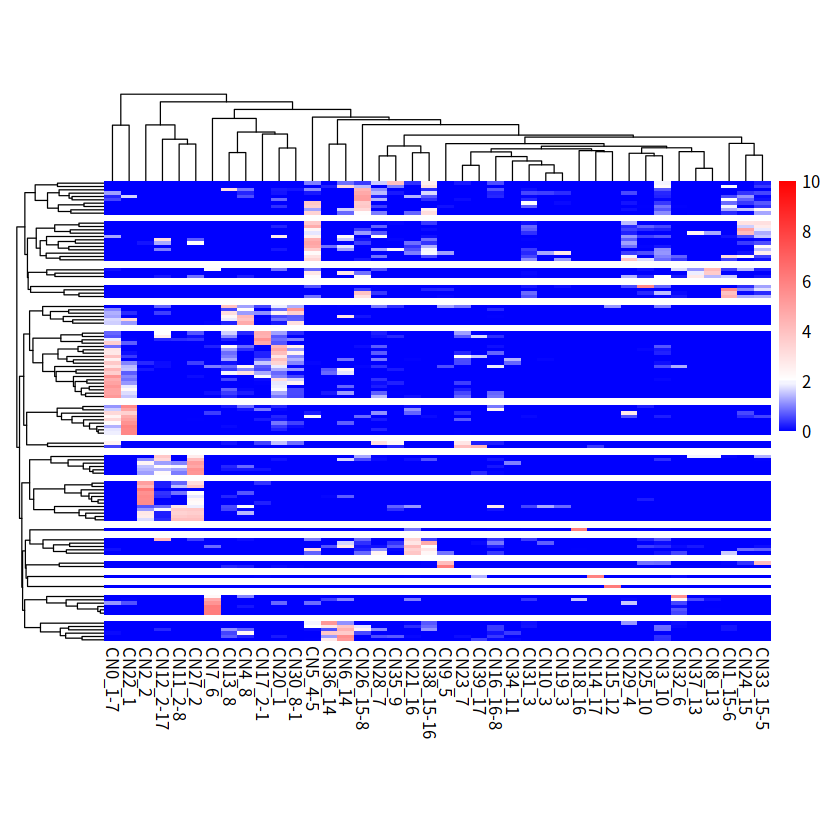

In [2]:
gc_csd_CN_anno = gc_csd_CN_annoAll_CN
# CN percentages in each region/class -----------------------------------------------------------

cells_CN <- gc_csd_CN_annoAll_CN %>% dplyr::select(Class, All_CN)


dat <- as.data.frame(with(cells_CN, table(Class, All_CN)))
cells_CN_Freq <- spread(dat, All_CN, Freq)

dat_CN_freq <- cells_CN_Freq[,-1]
row.names(dat_CN_freq) <- cells_CN_Freq$Class


dat_CN_percent <- dat_CN_freq / rowSums(dat_CN_freq) * 100
row.names(dat_CN_percent)<- cells_CN_Freq$Class





# TP definition -----------------------------------------------------

####
bk <- c(seq(0,1.9,by=0.01),seq(2,10,by=0.01))
p <- pheatmap(dat_CN_percent,
         cellwidth = 10,
         cellheight = 2,
         # annotation_row = df_TP,
         border=FALSE,
         color=c(colorRampPalette(colors=c("blue","white"))(length(bk)/5),colorRampPalette(color=c("white","red"))(length(bk)*4/5)),
         scale = 'row',
         cluster_rows = T,
         show_rownames = F,
         show_colnames = T,
         legend_breaks=seq(0,10,2),
         breaks=bk,
         cutree_rows = 17)

##

row_cluster <- as.data.frame(cutree(p$tree_row,k=17))
table(row_cluster)
names(row_cluster) <- 'PhenoGraph'
row_cluster$Class <-  row.names(row_cluster)


In [68]:
pdf(file = "7_pheatmap_AllCN_split.pdf", width =10, height = 15)
print(p)
dev.off()

pdf 
  2

In [69]:
head(dat_CN_percent,2)

,CN0_1-7,CN1_15-6,CN10_3,CN11_2-8,CN12_2-17,CN13_8,CN14_17,CN15_12,CN16_16-8,CN17_2-1,⋯,CN36_14,CN37_13,CN38_15-16,CN39_17,CN4_8,CN5_4-5,CN6_14,CN7_6,CN8_13,CN9_5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mADT-1.tsv,1.819729,2.6772272,0.09164103,0.01963736,1.374615,1.099692,0,0,0.4189304,0.7134909,⋯,0.8771356,11.97225,2.061923,0.00000000,0.137461543,16.74413,17.05178,0.56948354,21.37854,0.01309158
mADT-10.tsv,0.000000,0.5009016,0.56100982,0.00000000,1.322380,0.000000,0,0,0.0000000,0.1602885,⋯,0.0000000,0.00000,3.012088,0.05342951,0.006678688,17.65845,0.00000,0.01335738,0.00000,0.00000000


pdf 
  2

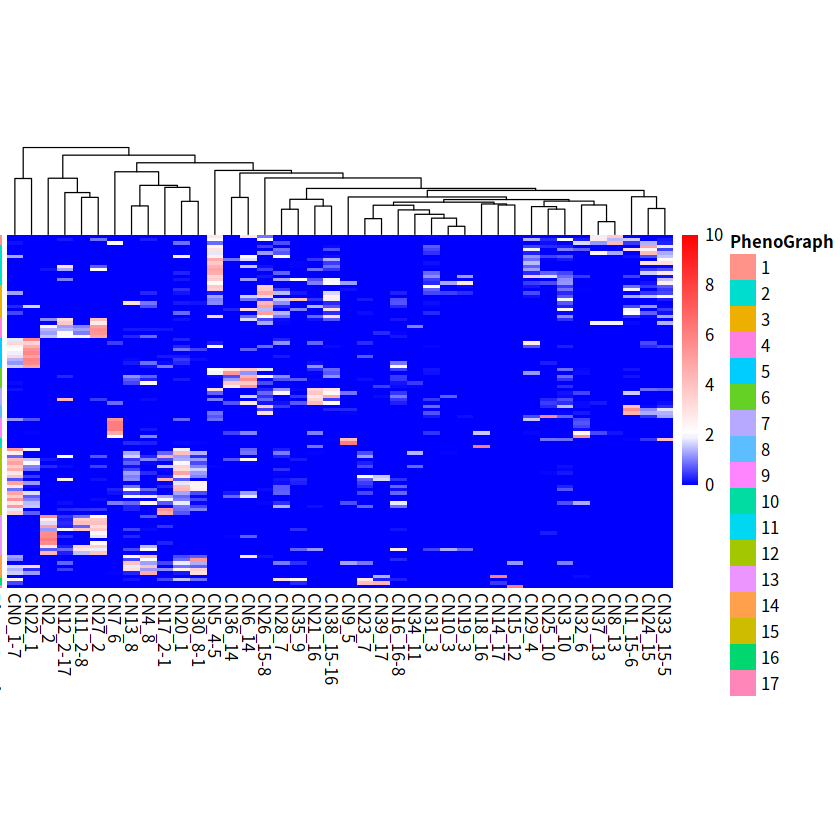

In [3]:
dat_CN_percent_class <- dat_CN_percent
dat_CN_percent_class$Class <- row.names(dat_CN_percent)

df_merge <- merge(row_cluster,dat_CN_percent_class,by='Class')

##
df_merge <- df_merge[order(df_merge$PhenoGraph),]
temp <- df_merge[,c(-1,-2)]
row.names(temp) <- df_merge$Class 

anno <- df_merge[2]
row.names(anno) <- df_merge$Class
anno$PhenoGraph <- as.factor(anno$PhenoGraph)

p1 <- pheatmap(temp,
               cellwidth = 10,
               cellheight = 2,
               annotation_row = anno,
               border=FALSE,
               color=c(colorRampPalette(colors=c("blue","white"))(length(bk)/5),colorRampPalette(color=c("white","red"))(length(bk)*4/5)),
               scale = 'row',
               cluster_rows = F,
               show_rownames = F,
               show_colnames = T,
               legend_breaks=seq(0,10,2),
               breaks=bk,
               cutree_rows = 17)

pdf(file = "7_pheatmap_AllCN.pdf", width =10, height = 15)
print(p1)
dev.off()




[1] 106  40

pdf 
  2

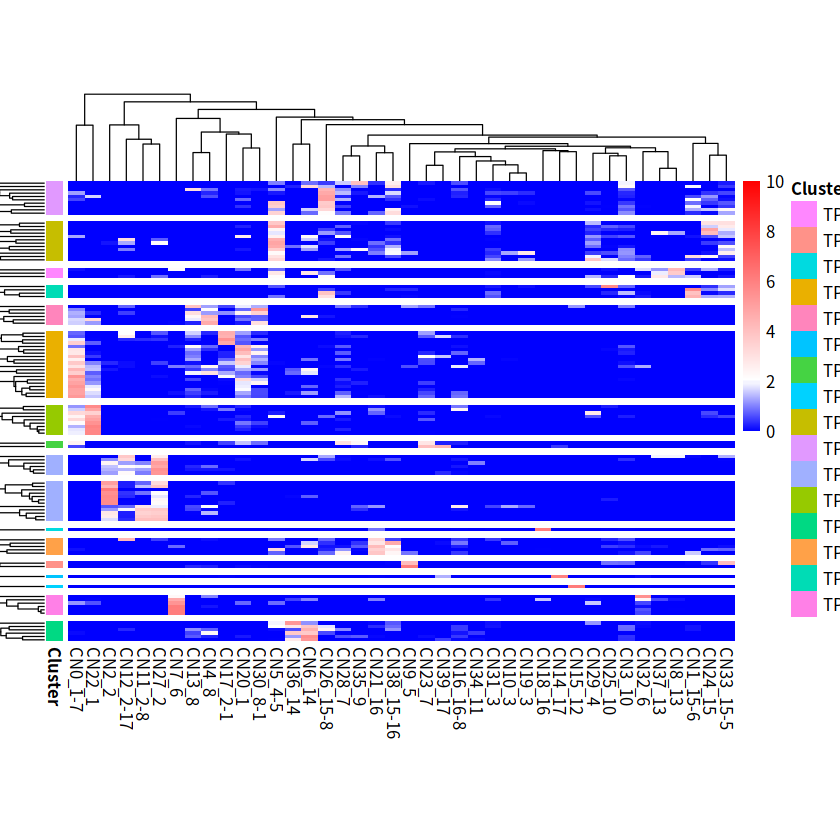

In [4]:
dim(temp)
####
row_cluster$Cluster <- row_cluster$PhenoGraph
row_cluster$Cluster[row_cluster$Cluster== 1] <- 'TP_1'
row_cluster$Cluster[row_cluster$Cluster== 2] <- 'TP_2'
row_cluster$Cluster[row_cluster$Cluster== 3] <- 'TP_3'
row_cluster$Cluster[row_cluster$Cluster== 4] <- 'TP_4-13'
row_cluster$Cluster[row_cluster$Cluster== 5] <- 'TP_5'
row_cluster$Cluster[row_cluster$Cluster== 6] <- 'TP_6'
row_cluster$Cluster[row_cluster$Cluster== 7] <- 'TP_7'
row_cluster$Cluster[row_cluster$Cluster== 8] <- 'TP_8'
row_cluster$Cluster[row_cluster$Cluster== 9] <- 'TP_9'
row_cluster$Cluster[row_cluster$Cluster== 10] <- 'TP_10'
row_cluster$Cluster[row_cluster$Cluster== 11] <- 'TP_11'
row_cluster$Cluster[row_cluster$Cluster== 12] <- 'TP_12'
row_cluster$Cluster[row_cluster$Cluster== 13] <- 'TP_4-13'
row_cluster$Cluster[row_cluster$Cluster== 14] <- 'TP_14'
row_cluster$Cluster[row_cluster$Cluster== 15] <- 'TP_15'
row_cluster$Cluster[row_cluster$Cluster== 16] <- 'TP_16'
row_cluster$Cluster[row_cluster$Cluster== 17] <- 'TP_17'

dat_CN_percent_class <- dat_CN_percent
dat_CN_percent_class$Class <- row.names(dat_CN_percent)

df_merge <- merge(row_cluster,dat_CN_percent_class,by='Class')

##
temp <- df_merge[,c(-1,-2,-3)]
row.names(temp) <- df_merge$Class 

anno <- df_merge[3]
row.names(anno) <- df_merge$Class

p1 <- pheatmap(temp,
               cellwidth = 10,
               cellheight = 2,
               annotation_row = anno,
               border=FALSE,
               color=c(colorRampPalette(colors=c("blue","white"))(length(bk)/5),colorRampPalette(color=c("white","red"))(length(bk)*4/5)),
               scale = 'row',
               cluster_rows = T,
               show_rownames = F,
               show_colnames = T,
               legend_breaks=seq(0,10,2),
               breaks=bk,
               cutree_rows = 17)

pdf(file = "8_anno_pheatmap_AllCN.pdf", width =10, height = 15)
print(p1)
dev.off()


In [5]:
# TP combined with clinical information

mydata_pheno <- merge(row_cluster,dat_CN_percent_class,by='Class')
row.names(mydata_pheno) <- dat_CN_percent_class$Class
mydata_pheno$Class0 <- rownames(mydata_pheno)
mydata_pheno$Class0 <- as.character(mydata_pheno$Class0)

# load("../HCC401_new.Rdata")
# HCCpathology <- df_training_new
# HCCpathology$Class <- paste0(HCCpathology$TMA, "_reg",sprintf("%03d",HCCpathology$Reg))

# for (i in 1:length(mydata_pheno$Class)) {
#   temp<-strsplit(mydata_pheno$Class,'_')[[i]][1]
#   temp1 <-strsplit(temp,"A")[[1]][2]
#   temp2 <- strsplit(mydata_pheno$Class,'_')[[i]][3]
#   mydata_pheno$Class[i]<- paste0(temp1,"_",temp2)
# }

# mydata_pheno_anno <- merge(mydata_pheno, HCCpathology, by="Class")

# write.csv(mydata_pheno_anno, file = 'mydata_pheno_anno.csv')



############SP definition ######
####

colnames(dat_CN_freq) <- gsub("-", "_", colnames(dat_CN_freq))
dat_selCN_freq <- dat_CN_freq %>% mutate(CN_tumor=(CN0_1_7 + CN22_1 + CN17_2_1 + CN20_1 + CN30_8_1 + CN28_7 + CN23_7 + CN39_17)) %>%  select(CN_tumor,
                                                                                  starts_with('CN1_'),
starts_with('CN2_'),
starts_with('CN3_'),
starts_with('CN4_'),
starts_with('CN5_'),
starts_with('CN6_'),
starts_with('CN7_'),
starts_with('CN8_'),
starts_with('CN9_'),
starts_with('CN10_'),
starts_with('CN11_'),
starts_with('CN12_'),
starts_with('CN13_'),
starts_with('CN14_'),
starts_with('CN15_'),
starts_with('CN16_'),
starts_with('CN18_'),
starts_with('CN19_'),
#starts_with('CN20_'),
starts_with('CN21_'),
starts_with('CN22_'),  # excluded: used only in CN_tumor sum
starts_with('CN24_'),
starts_with('CN25_'),
starts_with('CN26_'),
starts_with('CN27_'),
starts_with('CN28_'),
starts_with('CN29_'),
starts_with('CN30_'),
starts_with('CN31_'),
starts_with('CN32_'),
starts_with('CN33_'),
starts_with('CN34_'),
starts_with('CN35_'),
starts_with('CN36_'),
starts_with('CN37_'),
starts_with('CN38_'))
#starts_with('CN39_'))
# Excluded: CN0, CN17, CN22, CN23 (only used in CN_tumor, not kept as separate columns)
dat_selCN_percent <- dat_selCN_freq / rowSums(dat_selCN_freq) * 100
dat_selCN_percent_scale <- scale(dat_selCN_percent[,-1])

Run Rphenograph starts:
  -Input data of 106 rows and 35 columns
  -k is set to 15



  Finding nearest neighbors...DONE ~ 0.002 s
  Compute jaccard coefficient between nearest-neighbor sets...DONE ~ 0.006 s
  Build undirected graph from the weighted links...DONE ~ 0.007 s
  Run louvain clustering on the graph ...DONE ~ 0.002 s


Run Rphenograph DONE, totally takes 0.0169999999925494s.



  Return a community class
  -Modularity value: 0.5114639 
  -Number of clusters: 5

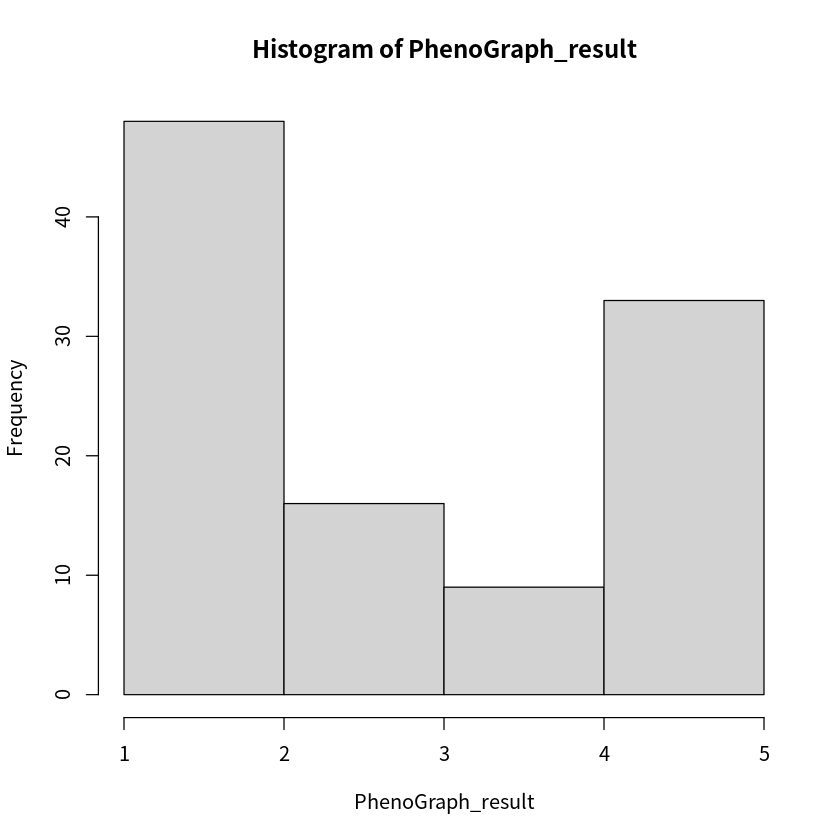

In [15]:
seed=123 
k <-15
res <- Rphenograph(dat_selCN_percent_scale,k=k)
PhenoGraph_result <-as.numeric(res[[2]]$membership)
#Checkpoint
hist(PhenoGraph_result,unique(PhenoGraph_result))
#Input: tSNE parameters
max_iter=1000   
perplexity=10  
seed=123      
theta=0.5     
dims = 2   

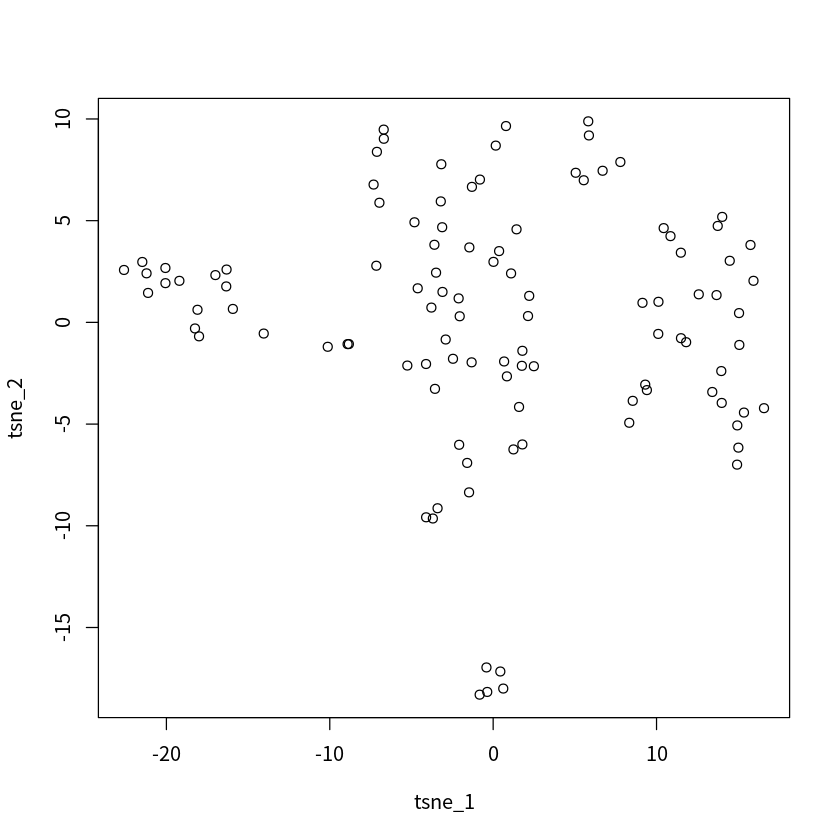

In [16]:
if (exists('seed')) set.seed(seed)
tsne_result <- Rtsne(dat_selCN_percent_scale,
                     initial_dims = ncol(dat_selCN_percent_scale),
                     pca = FALSE,
                     dims = dims,
                     check_duplicates = FALSE,
                     perplexity=perplexity,
                     max_iter=max_iter,
                     theta=theta)$Y
row.names(tsne_result)<-row.names(dat_selCN_percent_scale)
colnames(tsne_result)<-c("tsne_1","tsne_2")
plot(tsne_result)

,CN1_15_6,CN2_2,CN3_10,CN4_8,CN5_4_5,CN6_14,CN7_6,CN8_13,CN9_5,CN10_3,⋯,CN32_6,CN33_15_5,CN34_11,CN35_9,CN36_14,CN37_13,CN38_15_16,tsne_1,tsne_2,PhenoGraph
mADT-1.tsv,0.05688864,-0.3487613,-0.04759177,-0.5535990,1.5961778,1.9192631,-0.2321713,6.5509061,-0.2016569,-0.339306257,⋯,-0.1258726,-0.45111106,-0.2392718,-0.4472349,-0.1299987,4.6324449,-0.10869487,-0.8262439,-18.302186,1
mADT-10.tsv,-0.28652676,-0.3487613,0.57188515,-0.5797783,1.7532770,-0.5033349,-0.2703056,-0.2267525,-0.2035224,0.002619029,⋯,-0.3054569,2.17058900,-0.2392718,-0.4856690,-0.3086229,-0.2671174,0.09762149,14.0195286,5.185495,2
mADT-11.tsv,0.83023891,-0.3487613,0.94710922,-0.4396732,2.6771921,-0.5033349,-0.2484423,-0.2267525,-0.1443329,-0.226725558,⋯,-0.1890942,0.72709581,-0.2392718,-0.4856690,-0.3086229,-0.2671174,-0.31421714,16.5776088,-4.218030,2
mADT-12.tsv,1.50476089,-0.3487613,1.48806927,-0.5067387,1.9580149,-0.4304008,-0.2637443,-0.2267525,0.2260587,-0.303333145,⋯,0.1446282,0.32749134,-0.2392718,-0.4856690,-0.3086229,-0.2671174,-0.35165178,15.3511305,-4.433878,2
mADT-13.tsv,-0.33181382,-0.3487613,0.31976243,0.0928642,-0.1946117,-0.5033349,-0.2712369,-0.2267525,-0.1614890,2.505724373,⋯,-0.3048155,0.27715253,-0.2392718,0.6026484,-0.3086229,-0.2671174,1.17855725,13.9635910,-2.393635,2
mADT-14.tsv,-0.26394885,0.1084252,0.53925605,-0.5203103,-0.5171345,0.8854479,-0.2646329,-0.2267525,-0.2003566,-0.298963680,⋯,-0.2756952,-0.03250932,-0.2392718,-0.4014239,-0.1155896,-0.2671174,0.56464866,0.1593137,8.689988,3


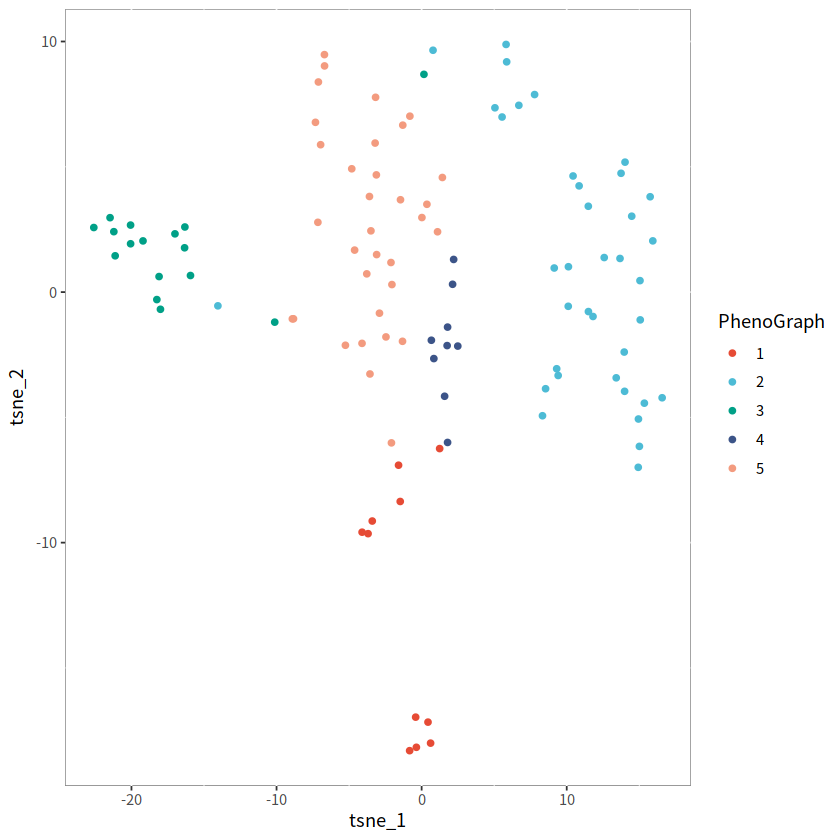

In [17]:
combined_data_analysed <- cbind(dat_selCN_percent_scale,
                                tsne_result,
                                PhenoGraph = PhenoGraph_result)

#Checkpoint
head(combined_data_analysed) 
combined_data_analysed <- as.data.frame(combined_data_analysed)

combined_data_analysed$PhenoGraph  <-as.factor(combined_data_analysed$PhenoGraph)
centers<-combined_data_analysed %>%
  group_by(PhenoGraph)  %>%
  summarise(tsne_1=median(tsne_1),tsne_2=median(tsne_2))

mytheme <- theme(panel.background = element_rect(fill = "white", colour = "black", size = 0.2), #坐标系及坐标轴
                 legend.key = element_rect(fill = "white", colour = "white"), #图标
                 legend.background = (element_rect(colour= "white", fill = "white")))


ggplot(combined_data_analysed)+
  geom_point(aes(x=tsne_1,y=tsne_2,colour=PhenoGraph))+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(6)))

[1] 1 2 3 4 5
Levels: 1 2 3 4 5

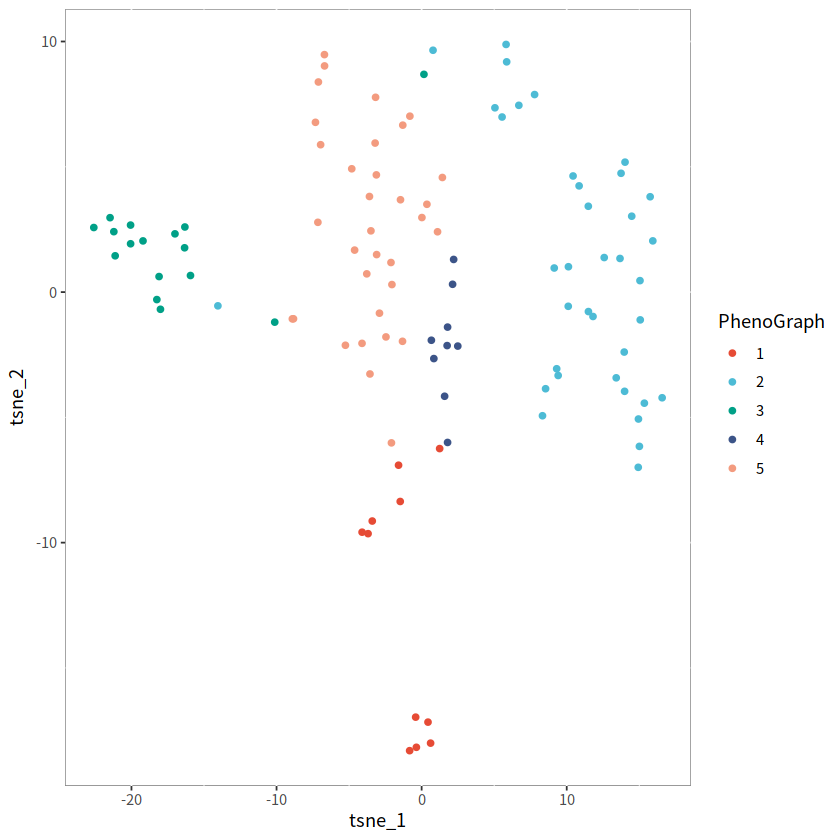

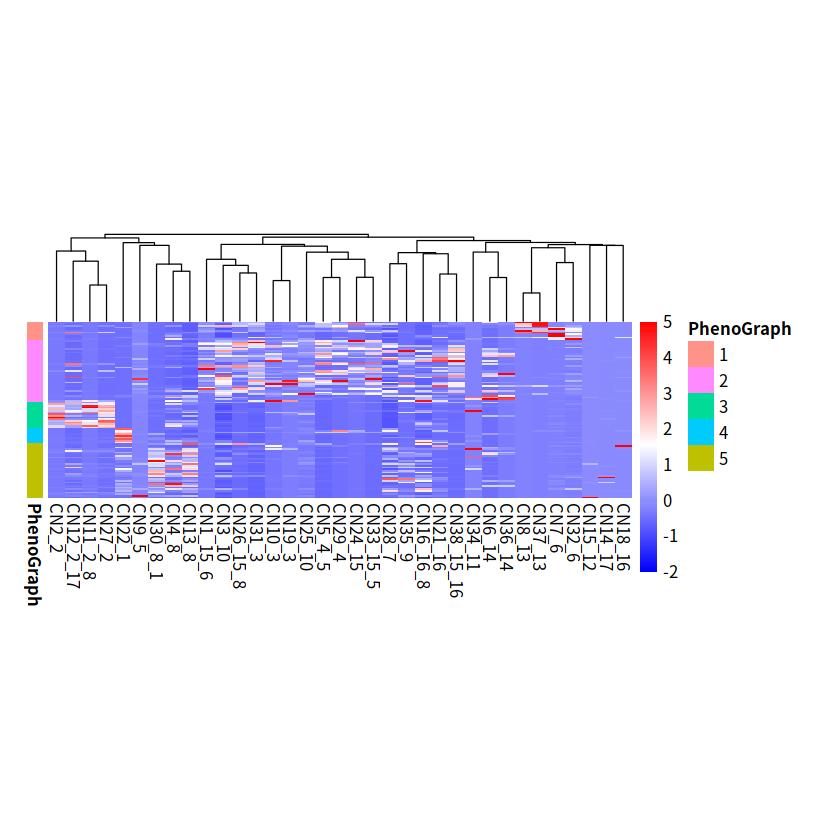

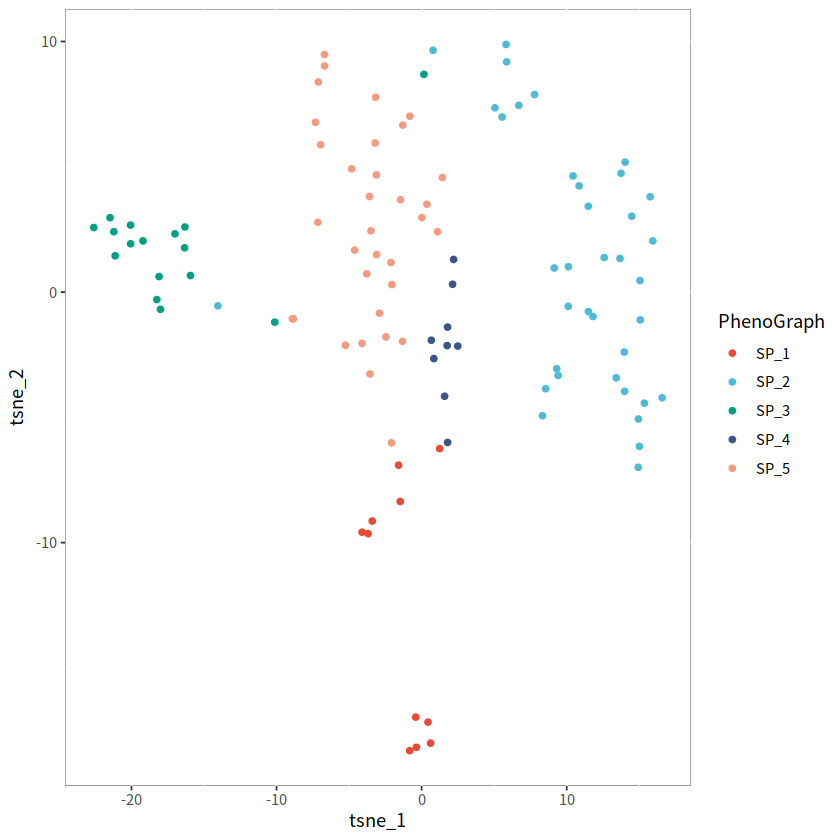

In [18]:
##tsne
ggplot(combined_data_analysed)+
  geom_point(aes(x=tsne_1,y=tsne_2,colour=PhenoGraph))+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(6)))
##################phenograph heatmap, selected CN
sortdata <- combined_data_analysed[order(combined_data_analysed$PhenoGraph),]
unique(sortdata$PhenoGraph)
# sortdata$PhenoGraph <- as.character(sortdata$PhenoGraph)
annotation_row<-select(sortdata, PhenoGraph)

temp1 <- sortdata[,1:dim(dat_selCN_percent_scale)[2]]

bk <- c(seq(-2,-0.1,by=0.01),seq(0,5,by=0.01))

pheatmap(temp1,
         cellwidth = 10,
         cellheight = 1,
         annotation_row = annotation_row,
         border=FALSE,
         color=c(colorRampPalette(colors=c("blue","white"))(length(bk)/2),colorRampPalette(color=c("white","red"))(length(bk)/2)),
         scale = "none",
         cluster_rows = F,
         show_rownames = F,
         breaks = bk)

##annotation
combined_data_analysed$PhenoGraph <- as.character(combined_data_analysed$PhenoGraph)
combined_data_analysed$PhenoGraph[combined_data_analysed$PhenoGraph=='1'] <- 'SP_1'
combined_data_analysed$PhenoGraph[combined_data_analysed$PhenoGraph=='2'] <- 'SP_2'
combined_data_analysed$PhenoGraph[combined_data_analysed$PhenoGraph=='3'] <- 'SP_3'
combined_data_analysed$PhenoGraph[combined_data_analysed$PhenoGraph=='4'] <- 'SP_4'
combined_data_analysed$PhenoGraph[combined_data_analysed$PhenoGraph=='5'] <- 'SP_5'
#combined_data_analysed$PhenoGraph[combined_data_analysed$PhenoGraph=='6'] <- 'SP_LII'
##tsne
ggplot(combined_data_analysed)+
  geom_point(aes(x=tsne_1,y=tsne_2,colour=PhenoGraph))+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(6)))

[1] "SP_1" "SP_2" "SP_3" "SP_4" "SP_5"

pdf 
  3

pdf 
  3

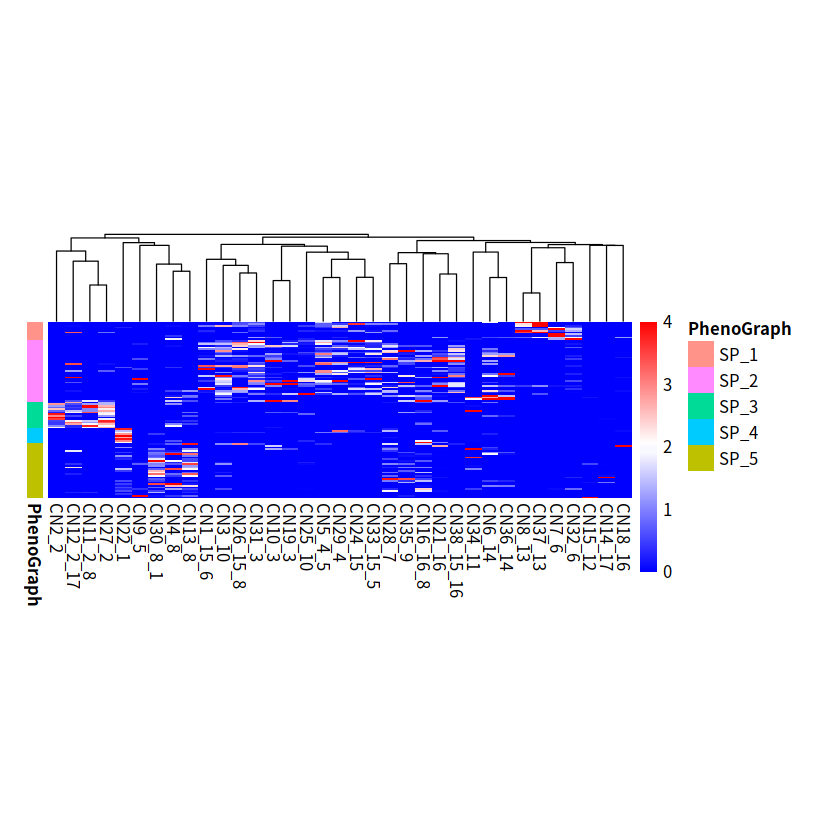

In [19]:
##################phenograph heatmap, selected CN
sortdata <- combined_data_analysed[order(combined_data_analysed$PhenoGraph),]
unique(sortdata$PhenoGraph)
# sortdata$PhenoGraph <- as.character(sortdata$PhenoGraph)
annotation_row<-select(sortdata, PhenoGraph)

temp1 <- sortdata[,1:dim(dat_selCN_percent_scale)[2]]

bk <- c(seq(0,1.9,by=0.01),seq(2,4,by=0.01))

pdf(file = "9_pheatmape_phenograph_K=30_5SP_anno.pdf", width =10, height = 15)
pheatmap(temp1,
         cellwidth = 10,
         cellheight = 1,
         annotation_row = annotation_row,
         border=FALSE,
         color=c(colorRampPalette(colors=c("blue","white"))(length(bk)/2),colorRampPalette(color=c("white","red"))(length(bk)/2)),
         scale = "none",
         cluster_rows = F,
         show_rownames = F,
         breaks = bk)
dev.off()


pdf(file = "10_pheatmape_phenograph_K=30_5SP_class.pdf", width =10, height = 45)
pheatmap(temp1,
         cellwidth = 10,
         cellheight = 10,
         annotation_row = annotation_row,
         border=FALSE,
         color=c(colorRampPalette(colors=c("blue","white"))(length(bk)/2),colorRampPalette(color=c("white","red"))(length(bk)/2)),
         scale = "none",
         cluster_rows = F,
         show_rownames = T,
         breaks = bk)
dev.off()

In [20]:
tempZZ= combined_data_analysed

# 保存为CSV文件
write.csv(tempZZ, "dat_CN_percent_class.csv")


In [ ]:

############# SP combined with clinical information 
mydata_pheno <- combined_data_analysed
mydata_pheno$Class <- rownames(combined_data_analysed)
mydata_pheno$Class <- as.character(mydata_pheno$Class)
mydata_pheno$Class0 <- rownames(combined_data_analysed)
mydata_pheno$Class0 <- as.character(mydata_pheno$Class0)

library(tidyverse)
library(patchwork) 
library(reshape) #melt，cast
library(tidyr) #spread，gather
library(stringr)

#TP pattern
tissue_pattern <- read.csv('mydata_pheno_anno.csv',header = T,row.names = 1,stringsAsFactors = F)
#SP pattern
ImmuneInf <- read.csv('selCN_k=30_5SP_anno.csv',header = T,row.names = 1,stringsAsFactors = F)



tissue_pattern <- dplyr::select(tissue_pattern, Class0,Cluster)
colnames(tissue_pattern) <- c('Class','TP')
unique(tissue_pattern$TP)


ImmuneInf <- ImmuneInf %>% select(Class, SP=PhenoGraph)


TP_SP <- merge(tissue_pattern, ImmuneInf,by='Class')


colnames(gc_csd_CN_anno)
allCN <- select(gc_csd_CN_anno,All_CN,3:54,neighborhood10)
colnames(allCN)

allCN <- select(allCN,cellid,Class, All_CN,Allsubtypes,TumorSubtype,StromalSubtype,everything())



All_CN_TP <- merge(TP_SP,allCN, by='Class')
head(All_CN_TP)
colnames(All_CN_TP)
unique(All_CN_TP$TP)


unique(All_CN_TP$StromalSubtype)
All_CN_TP$celltype <- All_CN_TP$StromalSubtype
All_CN_TP$celltype[with(All_CN_TP,grepl("CD4T", celltype))] <-'CD4T'
All_CN_TP$celltype[with(All_CN_TP,grepl("CD8T", celltype))] <-'CD8T'
All_CN_TP$celltype[with(All_CN_TP,grepl("Macrophages", celltype))] <-'Macrophages'

All_CN_TP$celltype[All_CN_TP$StromalSubtype=="CD4T_FOXP3+_KI67+"|All_CN_TP$StromalSubtype=="CD4T_FOXP3+"] <- "Treg"
All_CN_TP$celltype[All_CN_TP$StromalSubtype=="Macrophages_CD11c+_HLA-DR+"|All_CN_TP$StromalSubtype=="Macrophages_HLA-DR+"] <- "APC"

unique(All_CN_TP$celltype)

save(All_CN_TP,file = 'All_CN_TP_0424.Rdata')
write.csv(All_CN_TP, file = 'All_CN_TP_0424.csv')



######################## export information of each region/class###################################

##########All CN
cells_CN <-dplyr::select(All_CN_TP, Class, All_CN)
dat <- as.data.frame(with(cells_CN, table(Class, All_CN)))
dat1 <- spread(dat, All_CN, Freq)
dat2 <- dat1[,-1]
dat_percent <- dat2 / rowSums(dat2) * 100
# names(dat_percent) <- paste0("AllCN",c(0:39))
dat_percent$Class <- dat1$Class
write.csv(dat_percent,file = 'class_allCN.csv')

####All subtype
cells_subtype <-dplyr::select(All_CN_TP, Class, Allsubtypes)
dat <- as.data.frame(with(cells_subtype, table(Class, Allsubtypes)))
dat1 <- spread(dat, Allsubtypes, Freq)
dat2 <- dat1[,-1]
dat_percent <- dat2 / rowSums(dat2) * 100
dat_percent$Class <- dat1$Class
write.csv(dat_percent,file = 'class_allsubtypes.csv')

###All celltype
cells_celltype <-dplyr::select(All_CN_TP, Class, celltype)
dat <- as.data.frame(with(cells_celltype, table(Class, celltype)))
dat1 <- spread(dat, celltype, Freq)
dat2 <- dat1[,-1]
dat_percent <- dat2 / rowSums(dat2) * 100
dat_percent$Class <- dat1$Class
write.csv(dat_percent,file = 'class_celltype.csv')


####merge files
# rm(list=ls())
# gc()
allCN <- read.csv('class_allCN.csv',header = T,row.names = 1,stringsAsFactors = FALSE)
allsubtypes <- read.csv('class_allsubtypes.csv', header = T,row.names = 1,stringsAsFactors = FALSE)

allcelltype <- read.csv('class_celltype.csv', header = T,row.names = 1,stringsAsFactors = FALSE)
names(allcelltype)[1:11] <- paste0('celltype_',names(allcelltype)[1:11])



temp <- merge(allCN,allsubtypes,by='Class')
df_merge <- merge(temp, allcelltype,by='Class')


SP_anno <- read.csv(file='selCN_k=30_5SP_anno.csv',header = T,row.names = 1,stringsAsFactors = F)
SP_sel <- dplyr::select(SP_anno,Class ,SP=PhenoGraph)

TP_anno <- read.csv(file='mydata_pheno_anno.csv',header = T,row.names = 1,stringsAsFactors = F)
TP_sel <- dplyr::select(TP_anno,Class =  Class0, PhenoGraph, TP=Cluster, 45:106)


载入程辑包：‘reshape’


The following object is masked from ‘package:lubridate’:

    stamp


The following object is masked from ‘package:dplyr’:

    rename


The following objects are masked from ‘package:tidyr’:

    expand, smiths


Warning message in file(file, "rt"):
“无法打开文件'selCN_k=30_5SP_anno.csv': 没有那个文件或目录”


ERROR: Error in file(file, "rt"): 无法打开链结


In [62]:
TP_SP_merge <- merge(SP_sel,TP_sel,by='Class')

mydata_pheno_anno_TP <- merge(df_merge,TP_SP_merge,by='Class')
colnames(mydata_pheno_anno_TP)
dim(mydata_pheno_anno_TP)
write.csv(mydata_pheno_anno_TP,file = 'Class_Pheno_Anno.csv')

ERROR: Error: 找不到对象'SP_sel'
